In [2]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.charting import plot_price

# Load data
feed = DataFeed.from_dir('data/egx')

# Choose one stock
stock_index = 0
price = feed.close[:, stock_index]

print("Stock:", feed.symbols[stock_index])

Stock: ABUK


In [3]:
def sma(prices, window):
    prices = np.asarray(prices, dtype=float)
    out = np.full_like(prices, np.nan)

    for i in range(window - 1, len(prices)):
        out[i] = prices[i-window+1:i+1].mean()

    return out

In [4]:
ma9 = sma(price, 9)
ma20 = sma(price, 20)

In [5]:
cash = 1000.0         
shares = 0    
portfolio = []        
buy_days = []
sell_days = []
buy_count = 0
sell_count = 0

for i in range(len(price)):

    # Skip days before MA20 exists
    if np.isnan(ma9[i]) or np.isnan(ma20[i]):
        portfolio.append(cash)
        continue

    #  BUY 
    if ma9[i] > ma20[i] and shares == 0:

        shares = cash / price[i]
        cash = 0

        buy_days.append(i)
        buy_count += 1

    #  SELL 
    elif ma9[i] < ma20[i] and shares > 0:

        cash = shares * price[i]
        shares = 0

        sell_days.append(i)
        sell_count += 1

    value = cash + shares * price[i]
    portfolio.append(value)

In [6]:
if shares > 0:
    cash = shares * price[-1]
    shares = 0

final_value = cash

print("Final Portfolio Value =", round(final_value,2), "EGP")

Final Portfolio Value = 2855.17 EGP


In [7]:
portfolio = np.array(portfolio)

running_max = np.maximum.accumulate(portfolio)

drawdown = running_max - portfolio

max_drawdown = drawdown.max()

print("Maximum Drawdown =", round(max_drawdown,2), "EGP")

Maximum Drawdown = 1792.11 EGP


In [8]:
print("Buy Operations :", buy_count)
print("Sell Operations:", sell_count)

Buy Operations : 33
Sell Operations: 32


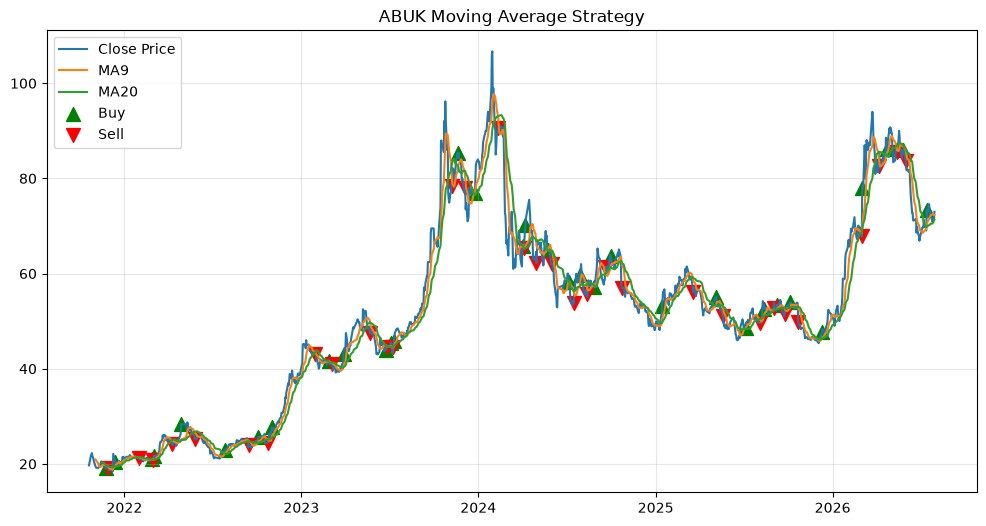

In [9]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(feed.dates, price, label='Close Price' )

ax.plot(feed.dates, ma9, label='MA9')
ax.plot(feed.dates, ma20, label='MA20')

ax.scatter(feed.dates[buy_days],
           price[buy_days],
           marker='^',
           s=100,
           label='Buy',
           color = "green")

ax.scatter(feed.dates[sell_days],
           price[sell_days],
           marker='v',
           s=100,
           label='Sell',
           color = "red")

ax.set_title(feed.symbols[stock_index] + " Moving Average Strategy")
ax.grid(alpha=0.3)
ax.legend()

plt.show()